# 🏺 MummyBot — Territory-Based RAG Pipeline

**New architecture — no LangChain, no Chroma, raw FAISS:**

```
Dynasty = Country   → tight cluster in vector space
Pharaoh = Individual → one anchor point per king  
Topic chunks = Rooms → baby chunks orbiting their king
```

**Strategy:**
- Each pharaoh gets one ANCHOR chunk (name + dynasty + 2 sentences)
- Topic chunks are prefixed with dynasty + pharaoh name → stay gravitationally close
- FAISS IndexFlatIP with L2-normalized vectors = exact cosine similarity
- Metadata stored separately as plain Python list — no DB overhead
- Retrieval filters by pharaoh name in Python — no ChromaDB filter syntax issues

**Install:**
```bash
pip install faiss-cpu sentence-transformers transformers
```


## Cell 1 — Imports & Config

In [25]:
import re
import json
import pickle
import shutil
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from IPython.display import Image, display
import faiss

INPUT_FILE  = Path("egypt_raw_data.md")
OUTPUT_DIR  = Path("data_clean")
INDEX_FILE  = Path("faiss_index.bin")
META_FILE   = Path("faiss_meta.pkl")
EMBED_MODEL = "BAAI/bge-small-en-v1.5"
MAX_TOKENS  = 450   # BGE-small supports 512, we use 450 to leave room for prefix

print(f"Input  : {INPUT_FILE} — exists: {INPUT_FILE.exists()}")
print(f"Output : {OUTPUT_DIR}")
print(f"Index  : {INDEX_FILE}")
print(f"Model  : {EMBED_MODEL}")
print("✅ Imports OK")


Input  : egypt_raw_data.md — exists: True
Output : data_clean
Index  : faiss_index.bin
Model  : BAAI/bge-small-en-v1.5
✅ Imports OK


## Cell 2 — Topic Rules

In [26]:
TOPIC_RULES = {
    "IDENTITY": [
        "was a pharaoh", "was an ancient egyptian", "was the first pharaoh",
        "was the second pharaoh", "was the third pharaoh", "was the fourth",
        "was the fifth", "was the sixth", "was the last pharaoh",
        "was the last king", "was the founder", "was a king", "was a queen",
        "was a kushite", "was a nubian", "was a macedonian",
        "reigned", "ruled egypt", "pharaoh of the", "king of the",
        "ascended the throne", "came to power", "took the throne",
        "his reign", "her reign",
    ],
    "REIGN": [
        "campaign", "military", "expedition", "conquered", "defeated",
        "invaded", "battle", "war", "army", "troops", "victory",
        "reformed", "reorganized", "established", "introduced", "policy",
        "trade", "diplomatic", "alliance", "treaty", "expelled",
        "restored", "reunited", "unified", "rebellion",
    ],
    "MONUMENTS": [
        "built", "constructed", "commissioned", "erected", "pyramid",
        "temple", "obelisk", "sphinx", "mortuary", "monument",
        "palace", "canal", "stele", "chapel", "complex",
        "karnak", "luxor", "giza", "saqqara", "abydos",
        "building project", "construction", "architecture",
    ],
    "FAMILY": [
        "son of", "daughter of", "father of", "mother of", "wife of",
        "husband of", "married", "children", "successor", "heir",
        "brother", "sister", "grandfather", "grandmother",
        "queen", "prince", "princess", "consort", "lineage",
    ],
    "DEATH": [
        "died", "death", "suicide", "assassinated", "murdered", "killed",
        "poison", "strangled", "execution", "fell in battle",
        "cause of death", "buried", "burial", "tomb", "mummy",
        "valley of the kings", "necropolis", "funeral",
    ],
    "LEGACY": [
        "legacy", "remembered", "known for", "famous for", "considered",
        "regarded as", "one of the greatest", "influence", "impact",
        "historically", "modern", "archaeolog", "discovered", "museum",
    ],
}

for topic, kws in TOPIC_RULES.items():
    print(f"  {topic:12} — {len(kws)} keywords")
print("✅ Topic rules loaded")


  IDENTITY     — 25 keywords
  REIGN        — 25 keywords
  MONUMENTS    — 23 keywords
  FAMILY       — 19 keywords
  DEATH        — 18 keywords
  LEGACY       — 14 keywords
✅ Topic rules loaded


## Cell 3 — Text Cleaner

In [27]:
def clean_text(text: str) -> str:
    text = re.sub(r'\[\d+\]', '', text)
    text = re.sub(r'\[note \d+\]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\[citation needed\]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\[[a-f]\]', '', text)
    text = re.sub(r'\(/[^)]+/[^)]*\)', '', text)
    text = re.sub(r'listenⓘ', '', text)
    text = re.sub(r'[\U00013000-\U0001342F]+', '', text)
    text = re.sub(r'\(Ancient Egyptian:[^)]+\)', '', text)
    text = re.sub(r'\(Koine Greek:[^)]+\)', '', text)
    text = re.sub(r'\(Ancient Greek:[^)]+\)', '', text)
    text = re.sub(r'\(Neo-Assyrian Akkadian:[^)]+\)', '', text)
    text = re.sub(r'\(Old Persian:[^)]+\)', '', text)
    text = re.sub(r'\*\*([^*]+)\*\*', r'\1', text)
    text = re.sub(r'\*([^*]+)\*', r'\1', text)
    text = re.sub(r'^\|.*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'[ \t]{2,}', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

sample = 'Khufu[1] (/ˈkuːfuː/; Ancient Egyptian: ḫwfw) was the second pharaoh[2].'
print("Before:", sample)
print("After :", clean_text(sample))


Before: Khufu[1] (/ˈkuːfuː/; Ancient Egyptian: ḫwfw) was the second pharaoh[2].
After : Khufu was the second pharaoh.


## Cell 4 — Sentence Classifier

In [28]:
def split_sentences(text: str) -> list:
    raw = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in raw if len(s.strip()) > 30]

def classify_sentence(sentence: str) -> str:
    lower  = sentence.lower()
    scores = {topic: 0 for topic in TOPIC_RULES}
    for topic, keywords in TOPIC_RULES.items():
        for kw in keywords:
            if kw in lower:
                scores[topic] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "IDENTITY"

def build_topic_sections(paragraphs: list) -> dict:
    sections = {topic: [] for topic in TOPIC_RULES}
    for para in paragraphs:
        for sent in split_sentences(para):
            topic = classify_sentence(sent)
            sections[topic].append(sent)
    return sections

# Test
tests = [
    "Khufu was the second pharaoh of the Fourth Dynasty.",
    "He commissioned the Great Pyramid of Giza.",
    "His mother was Hetepheres I.",
    "The cause of his death is not documented.",
    "Khufu has a conflicting legacy in ancient history.",
]
print(f"{'Sentence':60} → Topic")
print("-" * 75)
for s in tests:
    print(f"  {s[:58]:60} → {classify_sentence(s)}")


Sentence                                                     → Topic
---------------------------------------------------------------------------
  Khufu was the second pharaoh of the Fourth Dynasty.          → IDENTITY
  He commissioned the Great Pyramid of Giza.                   → MONUMENTS
  His mother was Hetepheres I.                                 → IDENTITY
  The cause of his death is not documented.                    → DEATH
  Khufu has a conflicting legacy in ancient history.           → LEGACY


## Cell 5 — Parse egypt_raw_data.md

In [29]:
def parse_raw_md(filepath: Path) -> dict:
    content  = filepath.read_text(encoding="utf-8")
    result   = {}
    sections = re.split(r'\n## ', content)
    for section in sections[1:]:
        lines   = section.strip().split("\n")
        dynasty = lines[0].strip()
        result[dynasty] = []
        pharaoh_blocks  = re.split(r'\n### ', section)
        for block in pharaoh_blocks[1:]:
            name      = block.strip().split("\n")[0].strip()
            src_match = re.search(r'\*\*Source:\*\*\s*(https?://\S+)', block)
            source    = src_match.group(1).strip() if src_match else ""
            raw = re.sub(r'\*\*Source:\*\*.*?\n', '', block, flags=re.DOTALL)
            raw = re.sub(r'---+', '', raw)
            raw = clean_text(raw)
            if "scrape failed" in raw.lower() or len(raw) < 50:
                continue
            paragraphs = [p.strip() for p in raw.split('\n\n') if len(p.strip()) > 40]
            if paragraphs:
                result[dynasty].append({
                    "name": name, "source": source, "paragraphs": paragraphs
                })
    return result

dynasties = parse_raw_md(INPUT_FILE)
total     = sum(len(v) for v in dynasties.values())
print(f"✅ {len(dynasties)} dynasties, {total} pharaohs\n")
for dynasty, pharaohs in dynasties.items():
    print(f"  {len(pharaohs):2}  {dynasty}")


✅ 19 dynasties, 84 pharaohs

   6  Dynasty 4 (Pyramid Builders ~2575–2465 BC)
  10  Dynasty 18 (New Kingdom Golden Age ~1550–1295 BC)
   6  Dynasty 19 (Ramesside Period ~1295–1186 BC)
   5  Dynasty 25 (Nubian Pharaohs ~712–664 BC)
   5  Ptolemaic Period (~304–30 BC)
   5  Dynasty 1–2 (Early Dynastic ~3100–2686 BC)
   3  Dynasty 3 (Old Kingdom ~2686–2613 BC)
   4  Dynasty 5 (Old Kingdom ~2494–2345 BC)
   3  Dynasty 6 (Old Kingdom ~2345–2181 BC)
   3  Dynasty 11 (Middle Kingdom ~2055–1985 BC)
   6  Dynasty 12 (Middle Kingdom ~1985–1773 BC)
   3  Dynasty 15 (Hyksos ~1650–1550 BC)
   2  Dynasty 17 (Theban ~1580–1550 BC)
   4  Dynasty 20 (Late Ramesside ~1186–1069 BC)
   3  Dynasty 21 (Third Intermediate ~1069–945 BC)
   3  Dynasty 22 (Libyan ~945–720 BC)
   6  Dynasty 26 (Saite Period ~664–525 BC)
   4  Dynasty 27 (First Persian ~525–404 BC)
   3  Dynasty 30 (Last Native ~380–343 BC)


## Cell 6 — Territory Chunking Strategy

Each pharaoh produces:
1. **ANCHOR chunk** — name + dynasty + first 2 sentences. This is the individual's point in the map.
2. **Topic baby chunks** — each prefixed with `dynasty + pharaoh` so they orbit their anchor.

Every chunk text starts with:
```
[Dynasty 19 Ramesside] [Ramesses II] MONUMENTS:
built Abu Simbel...
```

This forces the embedding model to place all Ramesses II chunks near each other
and all Dynasty 19 chunks in the same territory.


In [30]:
from transformers import AutoTokenizer
tokenizer_ = AutoTokenizer.from_pretrained("BAAI/bge-small-en-v1.5")

def token_count(text: str) -> int:
    return len(tokenizer_.encode(text, truncation=False))

def trim_to_tokens(text: str, max_tok: int) -> str:
    sentences = split_sentences(text)
    result, total = [], 0
    for s in sentences:
        t = token_count(s)
        if total + t > max_tok:
            break
        result.append(s)
        total += t
    return " ".join(result)

def split_to_token_chunks(text: str, max_tok: int, prefix: str) -> list:
    sentences  = split_sentences(text)
    chunks, current, cur_tok = [], [], 0
    for s in sentences:
        st = token_count(s)
        if cur_tok + st > max_tok and current:
            chunks.append(prefix + " ".join(current))
            current, cur_tok = [s], st
        else:
            current.append(s)
            cur_tok += st
    if current:
        chunks.append(prefix + " ".join(current))
    return chunks


def build_territory_chunks(dynasties: dict) -> list:
    """
    Returns list of dicts:
    {
      text     : str   — the actual text to embed
      pharaoh  : str   — exact pharaoh name
      dynasty  : str   — dynasty name
      topic    : str   — ANCHOR / IDENTITY / REIGN / MONUMENTS / FAMILY / DEATH / LEGACY
      source   : str   — wikipedia URL
      is_anchor: bool  — True = the king's main point
    }
    """
    chunks = []

    for dynasty, pharaohs in dynasties.items():
        # Short dynasty tag injected into every chunk text
        # e.g. "Dynasty 18 New Kingdom" → "[Dyn18NewKingdom]"
        dyn_tag = re.sub(r'[^a-zA-Z0-9]', '', dynasty[:30])

        for p in pharaohs:
            name   = p["name"]
            source = p["source"]
            paras  = p["paragraphs"]

            # Territory prefix — stamped on EVERY chunk for this pharaoh
            # Forces all chunks to orbit their king in vector space
            territory = f"[{dyn_tag}][{name}] "

            # ── 1. ANCHOR chunk ───────────────────────────────────────────
            # First 2 sentences — dense identity signal, one point per king
            intro    = " ".join(split_sentences(" ".join(paras[:2]))[:3])
            intro    = trim_to_tokens(intro, MAX_TOKENS - token_count(territory) - 20)
            anchor   = territory + intro

            chunks.append({
                "text":      anchor,
                "pharaoh":   name,
                "dynasty":   dynasty,
                "topic":     "ANCHOR",
                "source":    source,
                "is_anchor": True,
            })

            # ── 2. Topic baby chunks ──────────────────────────────────────
            sections = build_topic_sections(paras)

            for topic, sentences in sections.items():
                if not sentences:
                    continue
                body   = " ".join(sentences)
                if len(body) < 40:
                    continue

                # Prefix = territory tag + topic label
                # "  [Dyn19Ramesside][Ramesses II] MONUMENTS: ..."
                topic_prefix = territory + f"{topic}: "
                max_body_tok = MAX_TOKENS - token_count(topic_prefix) - 5

                if token_count(body) <= max_body_tok:
                    chunks.append({
                        "text":      topic_prefix + body,
                        "pharaoh":   name,
                        "dynasty":   dynasty,
                        "topic":     topic,
                        "source":    source,
                        "is_anchor": False,
                    })
                else:
                    # Split large sections into sub-chunks, all prefixed
                    sub_chunks = split_to_token_chunks(body, max_body_tok, topic_prefix)
                    for i, sub in enumerate(sub_chunks):
                        chunks.append({
                            "text":      sub,
                            "pharaoh":   name,
                            "dynasty":   dynasty,
                            "topic":     topic,
                            "source":    source,
                            "is_anchor": False,
                        })

    return chunks


chunks = build_territory_chunks(dynasties)

# ── Stats ─────────────────────────────────────────────────────────────────
tok_counts   = [token_count(c["text"]) for c in chunks]
topic_counts = Counter(c["topic"] for c in chunks)
over         = sum(1 for t in tok_counts if t > MAX_TOKENS)

print(f"Total chunks  : {len(chunks)}")
print(f"Anchor chunks : {sum(1 for c in chunks if c['is_anchor'])} (one per pharaoh)")
print(f"Baby chunks   : {sum(1 for c in chunks if not c['is_anchor'])}")
print(f"Over {MAX_TOKENS} tokens : {over}")
print(f"Min tokens    : {min(tok_counts)}")
print(f"Max tokens    : {max(tok_counts)}")
print(f"Avg tokens    : {int(sum(tok_counts)/len(tok_counts))}")
print(f"\nChunks per topic:")
for topic, cnt in topic_counts.most_common():
    print(f"  {topic:12} : {cnt}")

# Preview Khufu
print("\nKhufu chunks:")
for c in chunks:
    if c["pharaoh"] == "Khufu":
        print(f"  [{c['topic']:12}] {token_count(c['text']):3} tok  {c['text'][:90]}...")


Token indices sequence length is longer than the specified maximum sequence length for this model (553 > 512). Running this sequence through the model will result in indexing errors


Total chunks  : 540
Anchor chunks : 84 (one per pharaoh)
Baby chunks   : 456
Over 450 tokens : 0
Min tokens    : 33
Max tokens    : 443
Avg tokens    : 187

Chunks per topic:
  IDENTITY     : 128
  ANCHOR       : 84
  FAMILY       : 84
  MONUMENTS    : 78
  REIGN        : 68
  DEATH        : 63
  LEGACY       : 35

Khufu chunks:
  [ANCHOR      ]  96 tok  [Dynasty4PyramidBuilders2][Khufu] Khufu or Cheops was the second pharaoh of the Fourth Dyn...
  [IDENTITY    ] 387 tok  [Dynasty4PyramidBuilders2][Khufu] IDENTITY: Khufu or Cheops was the second pharaoh of the ...
  [IDENTITY    ] 204 tok  [Dynasty4PyramidBuilders2][Khufu] IDENTITY: Khufu is well known under his Hellenized name ...
  [REIGN       ]  66 tok  [Dynasty4PyramidBuilders2][Khufu] REIGN: In fact, several royal and religious titles intro...
  [MONUMENTS   ] 173 tok  [Dynasty4PyramidBuilders2][Khufu] MONUMENTS: He is generally accepted as having commission...
  [FAMILY      ] 247 tok  [Dynasty4PyramidBuilders2][Khufu] FAMILY: I

## Cell 7 — Embed with BGE + Store in FAISS

No LangChain. Raw SentenceTransformer + FAISS IndexFlatIP.

In [31]:
print("Loading BGE model...")
model = SentenceTransformer(EMBED_MODEL)

texts = [c["text"] for c in chunks]

print(f"Embedding {len(texts)} chunks...")
embeddings = model.encode(
    texts,
    batch_size=64,
    normalize_embeddings=True,   # L2 norm → inner product = cosine similarity
    show_progress_bar=True
)
embeddings = np.array(embeddings, dtype="float32")
print(f"Embedding shape: {embeddings.shape}")

# Build FAISS flat index — exact search, no approximation
dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)   # inner product on normalized = cosine
index.add(embeddings)
print(f"\nFAISS index: {index.ntotal} vectors, dim={dim}")

# Save index + metadata
faiss.write_index(index, str(INDEX_FILE))
with open(META_FILE, "wb") as f:
    pickle.dump(chunks, f)

print(f"✅ Saved: {INDEX_FILE}  ({INDEX_FILE.stat().st_size/1024:.0f} KB)")
print(f"✅ Saved: {META_FILE}  ({META_FILE.stat().st_size/1024:.0f} KB)")


Loading BGE model...
Embedding 540 chunks...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Embedding shape: (540, 384)

FAISS index: 540 vectors, dim=384
✅ Saved: faiss_index.bin  (810 KB)
✅ Saved: faiss_meta.pkl  (415 KB)


## Cell 8 — t-SNE Territory Map

Plots ANCHOR chunks only — one point per pharaoh.
Good territory = dynasties cluster separately, no two unrelated kings overlapping.

Running t-SNE on 84 anchor points...
✅ Saved: tsne_territories.png


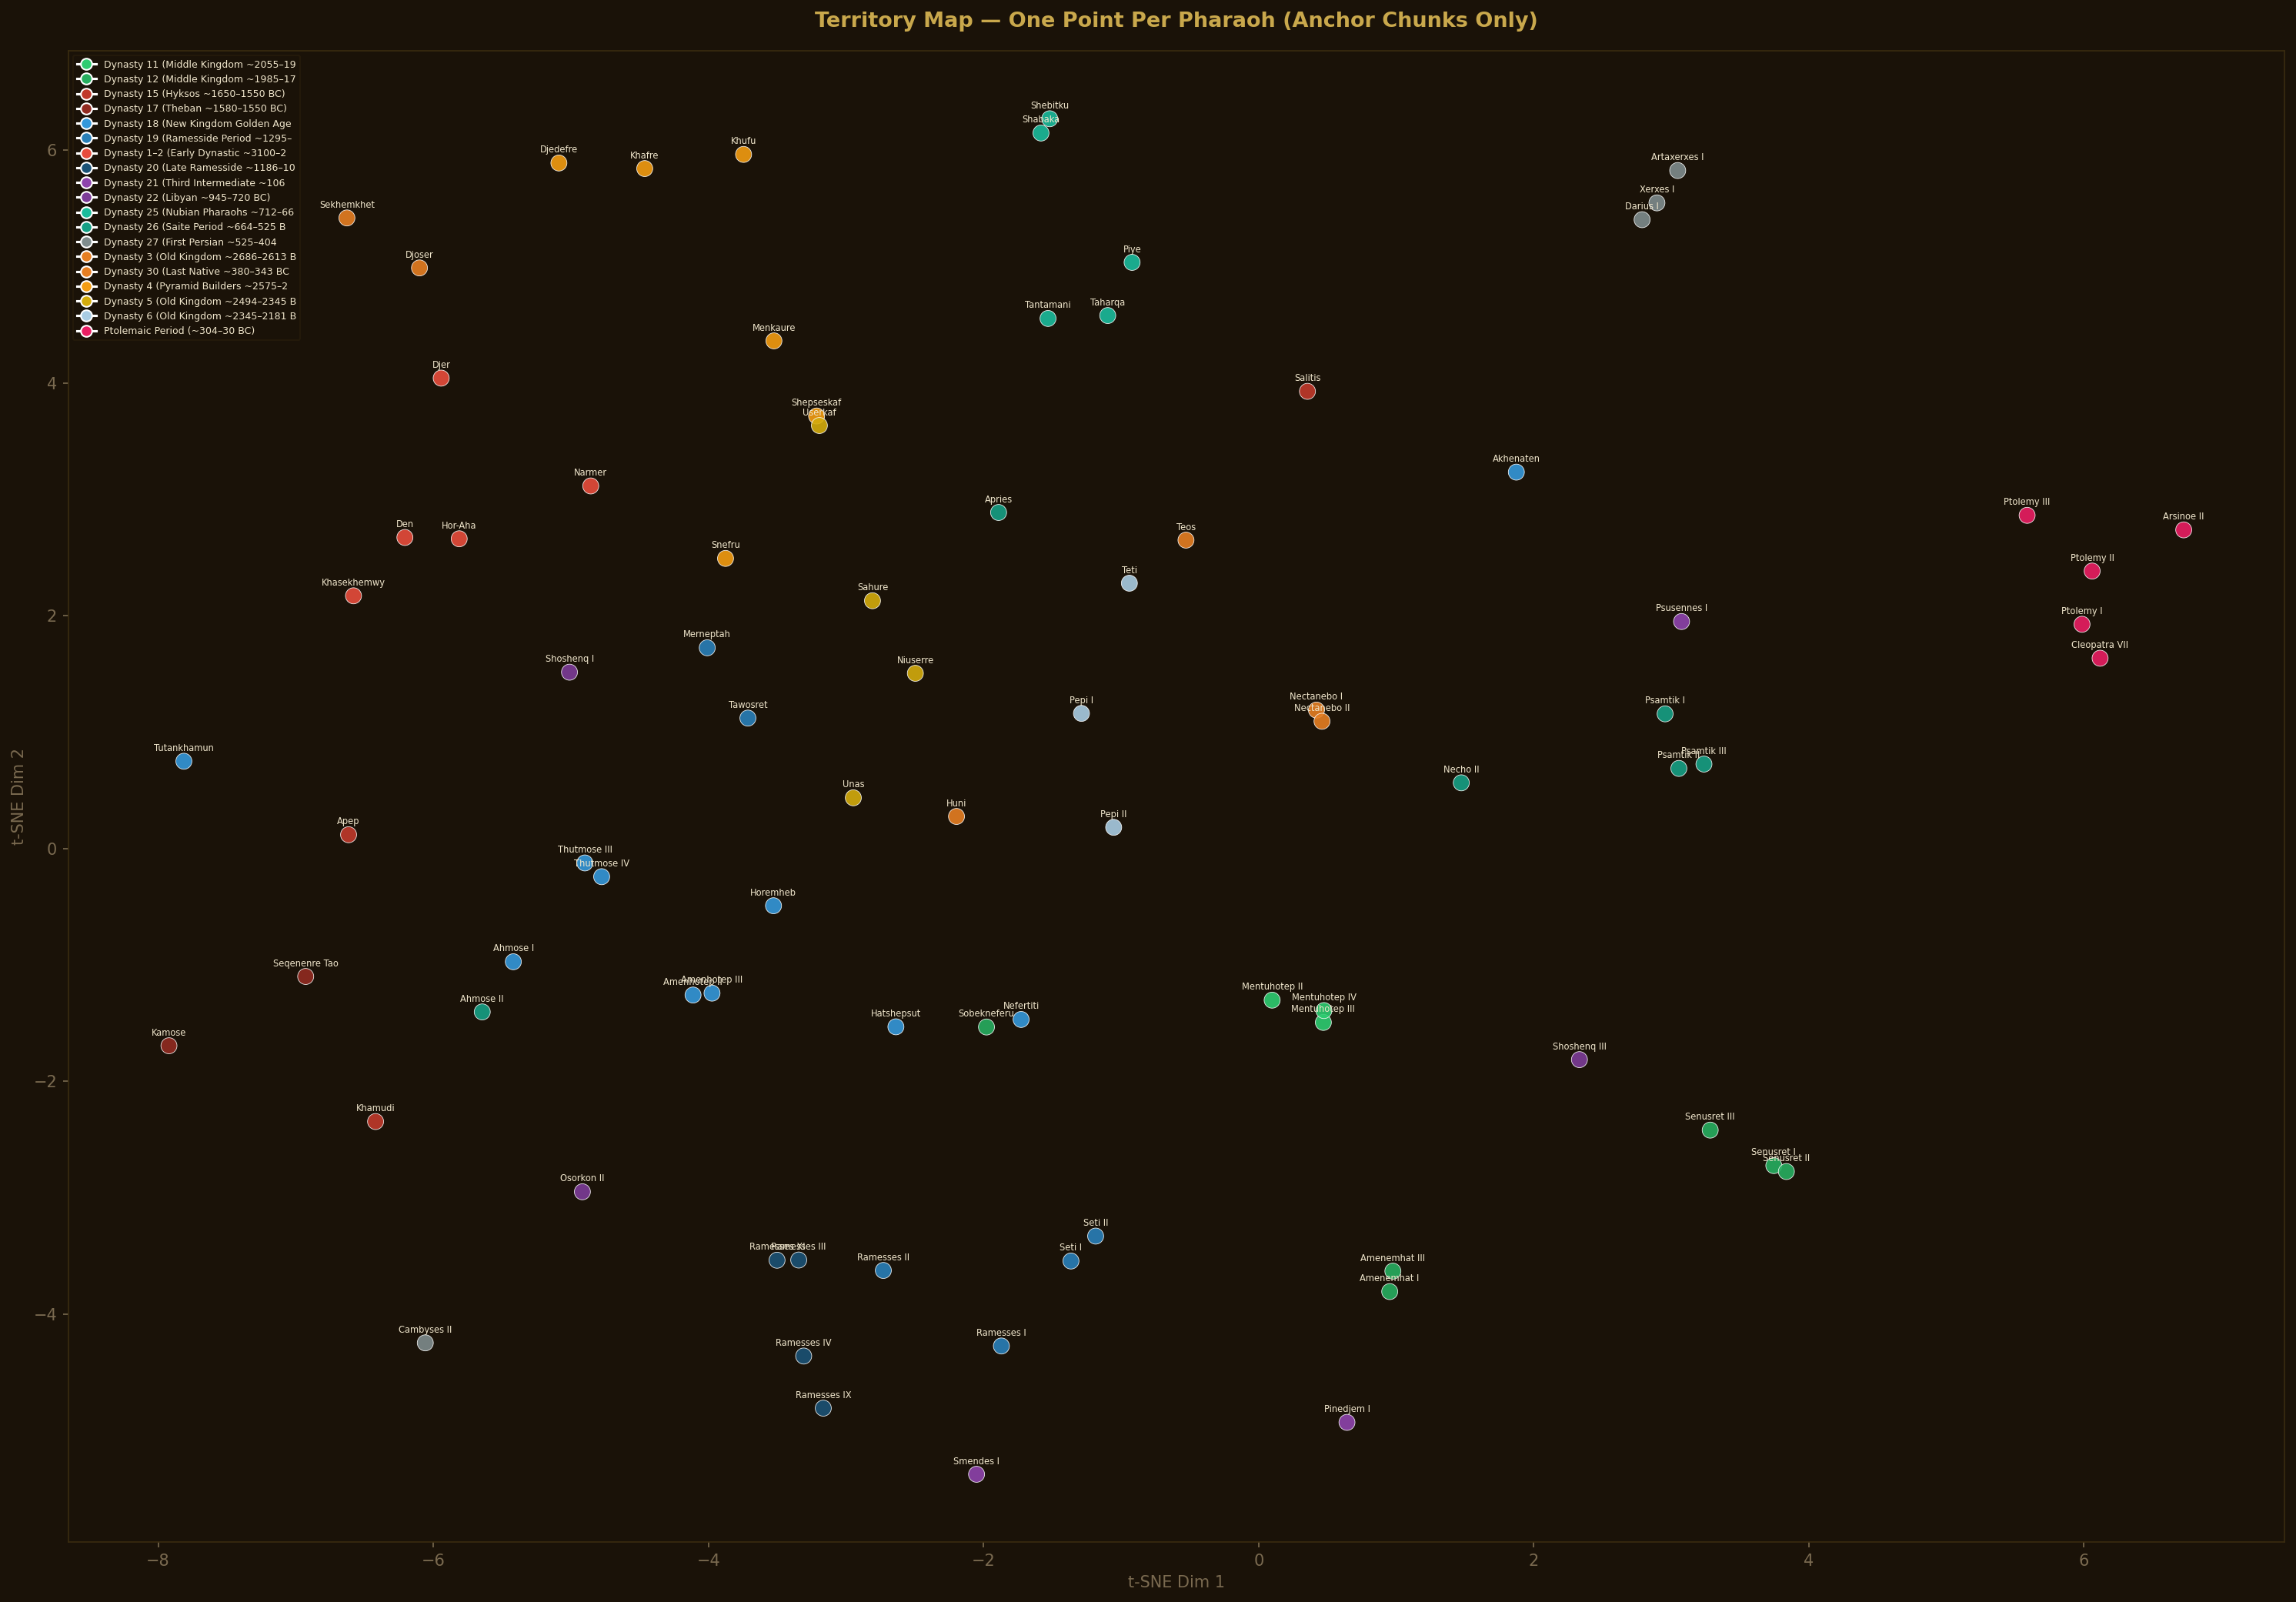

In [32]:
DYNASTY_COLORS = {
    "early dynastic": "#e74c3c", "dynasty 3":  "#e67e22",
    "dynasty 4":      "#f39c12", "dynasty 5":  "#d4ac0d",
    "dynasty 6":      "#a9cce3", "dynasty 11": "#2ecc71",
    "dynasty 12":     "#27ae60", "dynasty 15": "#c0392b",
    "dynasty 17":     "#922b21", "dynasty 18": "#3498db",
    "dynasty 19":     "#2980b9", "dynasty 20": "#1a5276",
    "dynasty 21":     "#8e44ad", "dynasty 22": "#7d3c98",
    "dynasty 25":     "#1abc9c", "dynasty 26": "#16a085",
    "dynasty 27":     "#7f8c8d", "dynasty 30": "#2c3e50",
    "ptolemaic":      "#e91e63",
}

def get_color(dynasty):
    d = dynasty.lower()
    for k, c in DYNASTY_COLORS.items():
        if k in d: return c
    return "#95a5a6"

# Only anchor chunks
anchor_idx  = [i for i, c in enumerate(chunks) if c["is_anchor"]]
anchor_vecs = embeddings[anchor_idx]
labels      = [chunks[i]["pharaoh"]  for i in anchor_idx]
dynasties_  = [chunks[i]["dynasty"]  for i in anchor_idx]
colors      = [get_color(d) for d in dynasties_]

print(f"Running t-SNE on {len(anchor_idx)} anchor points...")
tsne    = TSNE(n_components=2, perplexity=min(30, len(anchor_idx)-1),
               random_state=42, max_iter=1000)
reduced = tsne.fit_transform(anchor_vecs)

fig, ax = plt.subplots(figsize=(20, 14))
fig.patch.set_facecolor('#1a1208')
ax.set_facecolor('#1a1208')
ax.scatter(reduced[:, 0], reduced[:, 1],
           c=colors, s=100, alpha=0.9, edgecolors='white', linewidths=0.4)
for i, (x, y) in enumerate(reduced):
    ax.annotate(labels[i], (x, y), fontsize=5.5, color='#f0e6cc',
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

ax.set_title("Territory Map — One Point Per Pharaoh (Anchor Chunks Only)",
             color='#c9a84c', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("t-SNE Dim 1", color='#7a6a50')
ax.set_ylabel("t-SNE Dim 2", color='#7a6a50')
ax.tick_params(colors='#7a6a50')
for spine in ax.spines.values(): spine.set_edgecolor('#3a2c10')

seen = {}
for d, c in zip(dynasties_, colors):
    k = d[:35]
    if k not in seen: seen[k] = c
handles = [plt.Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=c, markersize=7, label=d)
           for d, c in sorted(seen.items())]
ax.legend(handles=handles, loc='upper left', fontsize=6,
          framealpha=0.3, facecolor='#1a1208',
          edgecolor='#3a2c10', labelcolor='#f0e6cc')

plt.tight_layout()
plt.savefig("tsne_territories.png", dpi=150, bbox_inches='tight', facecolor='#1a1208')
plt.close()
print("✅ Saved: tsne_territories.png")
display(Image("tsne_territories.png"))


## Cell 9 — Retrieval Functions

No LangChain filters. Pure FAISS search + Python post-filter by pharaoh name.

In [33]:
index  = faiss.read_index(str(INDEX_FILE))
with open(META_FILE, "rb") as f:
    chunks = pickle.load(f)
model  = SentenceTransformer(EMBED_MODEL)
print(f"✅ Loaded {index.ntotal} vectors")

QUERY_TOPIC_MAP = {
    "IDENTITY":  ["who is", "who was", "tell me about", "what was"],
    "MONUMENTS": ["built", "build", "construct", "pyramid", "temple", "monument"],
    "DEATH":     ["die", "died", "death", "killed", "how did", "cause", "buried"],
    "REIGN":     ["rule", "reign", "campaign", "battle", "war", "fight"],
    "FAMILY":    ["children", "wife", "husband", "son", "daughter", "family"],
    "LEGACY":    ["legacy", "famous", "known for", "remembered"],
}

PHARAOH_NAMES = sorted([
    "ramesses ii", "ramesses iii", "ramesses iv", "ramesses ix", "ramesses xi", "ramesses i",
    "thutmose iii", "thutmose iv", "thutmose ii", "thutmose i",
    "amenhotep iii", "amenhotep ii", "amenhotep i",
    "ptolemy iii", "ptolemy ii", "ptolemy i",
    "psamtik iii", "psamtik ii", "psamtik i",
    "pepi ii", "pepi i", "seti ii", "seti i",
    "mentuhotep iv", "mentuhotep iii", "mentuhotep ii",
    "senusret iii", "senusret ii", "senusret i",
    "amenemhat iii", "amenemhat ii", "amenemhat i",
    "nectanebo ii", "nectanebo i", "shoshenq iii", "shoshenq i",
    "khufu", "khafre", "menkaure", "snefru", "djedefre", "shepseskaf",
    "hatshepsut", "akhenaten", "tutankhamun", "horemheb", "nefertiti",
    "ahmose", "merneptah", "cleopatra vii", "cleopatra", "arsinoe",
    "djoser", "piye", "taharqa", "shabaka", "shebitku", "tantamani",
    "narmer", "tawosret", "kamose", "seqenenre",
    "cambyses", "darius", "xerxes", "artaxerxes",
    "osorkon", "psusennes", "pinedjem", "smendes",
    "userkaf", "sahure", "niuserre", "unas", "teti",
    "sobekneferu", "huni", "sekhemkhet",
], key=len, reverse=True)

def detect_topic(query):
    q = query.lower()
    for topic, keywords in QUERY_TOPIC_MAP.items():
        if any(kw in q for kw in keywords):
            return topic
    return None

def extract_pharaoh(query):
    q = query.lower()
    for name in PHARAOH_NAMES:
        if name in q:
            roman = {"i","ii","iii","iv","v","vi","vii","viii","ix","x","xi"}
            return " ".join(p.upper() if p in roman else p.title() for p in name.split())
    return None

def retrieve(query, k=3, verbose=False):
    # BGE query prefix
    bge_q = f"Represent this sentence for searching relevant passages: {query}"
    topic   = detect_topic(query)
    pharaoh = extract_pharaoh(query)

    if verbose:
        print(f"  Topic   : {topic}")
        print(f"  Pharaoh : {pharaoh}")

    # Embed query
    q_vec = model.encode([bge_q], normalize_embeddings=True).astype("float32")

    # FAISS search — get top candidates
    scores, indices = index.search(q_vec, k * 8)
    candidates = [(chunks[i], float(scores[0][j])) for j, i in enumerate(indices[0]) if i >= 0]

    # ── Post-filter by pharaoh name (exact Python match) ──────────────────
    if pharaoh:
         matched = [(c, s) for c, s in candidates
               if c["pharaoh"].lower() == pharaoh.lower()]  # exact match
         if matched:
           candidates = matched

    # ── Filter by topic ───────────────────────────────────────────────────
    if topic:
        topic_matched = [(c, s) for c, s in candidates if c["topic"] == topic]
        if topic_matched:
            candidates = topic_matched

    # Return top k by score
    candidates.sort(key=lambda x: x[1], reverse=True)

    if verbose:
        print(f"  Results : {len(candidates)} after filtering")

    return [c for c, s in candidates[:k]]


print("✅ Retrieval loaded")


✅ Loaded 540 vectors
✅ Retrieval loaded


## Cell 10 — Retrieval Test

In [34]:
test_queries = [
    ("Who was Khufu?",                      "IDENTITY",   "Khufu"),
    ("What did Ramesses II build?",          "MONUMENTS",  "Ramesses II"),
    ("How did Cleopatra die?",               "DEATH",      "Cleopatra VII"),
    ("Tell me about Djoser",                 "IDENTITY",   "Djoser"),
    ("Who were Hatshepsut's children?",      "FAMILY",     "Hatshepsut"),
    ("What was Khufu famous for?",           "LEGACY",     "Khufu"),
    ("What battles did Ramesses II fight?",  "REIGN",      "Ramesses II"),
    ("What did Thutmose III conquer?",       "REIGN",      "Thutmose III"),
    ("How did Tutankhamun die?",             "DEATH",      "Tutankhamun"),
    ("What did Hatshepsut build?",           "MONUMENTS",  "Hatshepsut"),
]

print(f"{'Query':45} {'Exp':10} {'Got Pharaoh':20} {'Got Topic':12} Score  Match")
print("─" * 105)
correct = 0
for query, exp_topic, exp_pharaoh in test_queries:
    results = retrieve(query, k=2)
    if results:
        r           = results[0]
        got_pharaoh = r["pharaoh"]
        got_topic   = r["topic"]
        pharaoh_ok  = exp_pharaoh.lower() in got_pharaoh.lower()
        topic_ok    = got_topic == exp_topic
        icon        = "✅" if pharaoh_ok and topic_ok else ("⚠️ " if pharaoh_ok else "❌")
        if pharaoh_ok and topic_ok: correct += 1
        print(f"  {query[:43]:45} {exp_topic:10} {got_pharaoh:20} {got_topic:12} {icon}")
    else:
        print(f"  {query[:43]:45} {exp_topic:10} {'NO RESULT':20} {'—':12} ❌")

print(f"\nScore: {correct}/{len(test_queries)}")


Query                                         Exp        Got Pharaoh          Got Topic    Score  Match
─────────────────────────────────────────────────────────────────────────────────────────────────────────
  Who was Khufu?                                IDENTITY   Khufu                IDENTITY     ✅
  What did Ramesses II build?                   MONUMENTS  Ramesses II          MONUMENTS    ✅
  How did Cleopatra die?                        DEATH      Cleopatra VII        DEATH        ✅
  Tell me about Djoser                          IDENTITY   Djoser               IDENTITY     ✅
  Who were Hatshepsut's children?               FAMILY     Hatshepsut           FAMILY       ✅
  What was Khufu famous for?                    LEGACY     Khufu                IDENTITY     ⚠️ 
  What battles did Ramesses II fight?           REIGN      Ramesses II          REIGN        ✅
  What did Thutmose III conquer?                REIGN      Thutmose III         ANCHOR       ⚠️ 
  How did Tutankhamun die?

## Cell 11 — Inspect Retrieved Chunks

In [35]:
def inspect(query, k=3):
    results = retrieve(query, k=k, verbose=True)
    print(f"\nQuery: {query}")
    print(f"{'='*65}")
    for i, r in enumerate(results):
        print(f"\nChunk {i+1}")
        print(f"  Pharaoh   : {r['pharaoh']}")
        print(f"  Dynasty   : {r['dynasty']}")
        print(f"  Topic     : {r['topic']}")
        print(f"  Is Anchor : {r['is_anchor']}")
        print(f"  Tokens    : {token_count(r['text'])}")
        print(f"\n  Full text:\n")
        print(r["text"])
        print()

inspect("What did Ramesses II build?")


  Topic   : MONUMENTS
  Pharaoh : Ramesses II
  Results : 3 after filtering

Query: What did Ramesses II build?

Chunk 1
  Pharaoh   : Ramesses II
  Dynasty   : Dynasty 19 (Ramesside Period ~1295–1186 BC)
  Topic     : MONUMENTS
  Is Anchor : False
  Tokens    : 49

  Full text:

[Dynasty19RamessidePeriod][Ramesses II] MONUMENTS: Ramesses ascended to the throne at age 25, and for the early part of his reign, he focused on building cities, temples, and monuments.


Chunk 2
  Pharaoh   : Ramesses I
  Dynasty   : Dynasty 19 (Ramesside Period ~1295–1186 BC)
  Topic     : MONUMENTS
  Is Anchor : False
  Tokens    : 197

  Full text:

[Dynasty19RamessidePeriod][Ramesses I] MONUMENTS: Ramesses appears to have taken charge of domestic matters: most memorably, he completed the second pylon at Karnak Temple, begun under Horemheb. Ramesses I's only known action was to order the provision of endowments for the aforementioned Nubian temple at Buhen and "the construction of a chapel and a temple (wh